In [1]:
!nvidia-smi | head -n 12
!pip -q install segmentation-models-pytorch

Mon Oct  5 15:09:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, glob, random
import numpy as np, pandas as pd, cv2, torch, torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

Device: cuda


In [5]:
!pip -q install datasets

from datasets import load_dataset, concatenate_datasets
import numpy as np, os, shutil
from PIL import Image

shutil.rmtree("kvasir_data", ignore_errors=True)
img_dir, mask_dir = "kvasir_data/images", "kvasir_data/masks"
os.makedirs(img_dir, exist_ok=True); os.makedirs(mask_dir, exist_ok=True)

ds = None
for repo in ["MedOtter/KvasirSEG", "MedOtter/kvasir-seg", "Angelou0516/kvasir-seg"]:
    try:
        d = load_dataset(repo)
        ds = concatenate_datasets([d[s] for s in d.keys()])   # train + val + test = sab
        print("Loaded from:", repo, "| splits:", list(d.keys()), "| total:", len(ds))
        break
    except Exception as e:
        print("Failed:", repo, "->", str(e)[:120])

assert ds is not None, "Teeno repos fail hue, error mujhe bhej dein"
print("Columns:", ds.column_names)

for i, row in enumerate(ds):
    name = f"{i:04d}.png"
    row["image"].convert("RGB").save(f"{img_dir}/{name}")
    m = (np.array(row["mask"].convert("L")) > 0).astype(np.uint8) * 255   # 0/1 ya 0/255, dono theek
    Image.fromarray(m).save(f"{mask_dir}/{name}")

print("Images:", len(os.listdir(img_dir)), "| Masks:", len(os.listdir(mask_dir)))

README.md:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  277MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 32.6MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/val-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/100 [00:00<?, ? examples/s]

Loaded from: MedOtter/KvasirSEG | splits: ['train', 'test', 'val'] | total: 1000
Columns: ['image', 'mask', 'image_id']
Images: 1000 | Masks: 1000


In [6]:
all_names = sorted(os.listdir(img_dir))
train_names, test_names = train_test_split(all_names, test_size=0.2, random_state=SEED)
print("Train:", len(train_names), "| Test:", len(test_names))

Train: 800 | Test: 200


In [7]:
def load_pair(name):
    img = cv2.cvtColor(cv2.imread(f"{img_dir}/{name}"), cv2.COLOR_BGR2RGB)
    m = cv2.imread(f"{mask_dir}/{name}", 0)
    if m.shape[:2] != img.shape[:2]:
        m = cv2.resize(m, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    return img, (m > 127).astype(np.uint8)

def dice_iou(pred, gt, eps=1e-8):
    pred, gt = pred.astype(bool), gt.astype(bool)
    inter = (pred & gt).sum()
    dice = (2 * inter + eps) / (pred.sum() + gt.sum() + eps)
    iou = (inter + eps) / ((pred | gt).sum() + eps)
    return float(dice), float(iou)

# ---------- Bounding box utilities ----------
def mask_to_box(mask):
    ys, xs = np.where(mask > 0)
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()], dtype=np.float32)

def clip_box(b, W, H):
    return np.array([np.clip(b[0], 0, W-1), np.clip(b[1], 0, H-1),
                     np.clip(b[2], 0, W-1), np.clip(b[3], 0, H-1)], dtype=np.float32)

def get_signs(idx):
    # fixed random direction per image (same direction for 5%, 10%, 20%)
    return np.random.default_rng(SEED + 1000 + idx).choice([-1, 1], size=2)

def shift_box(box, frac, signs, W, H):
    bw, bh = box[2] - box[0], box[3] - box[1]
    dx, dy = signs[0] * frac * bw, signs[1] * frac * bh
    return clip_box([box[0]+dx, box[1]+dy, box[2]+dx, box[3]+dy], W, H)

def scale_box(box, s, W, H):
    cx, cy = (box[0]+box[2])/2, (box[1]+box[3])/2
    hw, hh = (box[2]-box[0])*s/2, (box[3]-box[1])*s/2
    return clip_box([cx-hw, cy-hh, cx+hw, cy+hh], W, H)

# ---------- Image corruptions ----------
def c_blur(img, rng, sigma):
    s = sigma * max(img.shape[:2]) / 512   # severity relative to image size
    return cv2.GaussianBlur(img, (0, 0), s)

def c_noise(img, rng, std):
    n = rng.normal(0, std, img.shape)
    return np.clip(img.astype(np.float32) + n, 0, 255).astype(np.uint8)

def c_brightness(img, rng, f):
    return np.clip(img.astype(np.float32) * f, 0, 255).astype(np.uint8)

def c_contrast(img, rng, f):
    m = img.astype(np.float32).mean()
    return np.clip((img.astype(np.float32) - m) * f + m, 0, 255).astype(np.uint8)

CORRUPTIONS = {
    "blur_2":         lambda im, r: c_blur(im, r, 2),
    "blur_5":         lambda im, r: c_blur(im, r, 5),
    "noise_10":       lambda im, r: c_noise(im, r, 10),
    "noise_25":       lambda im, r: c_noise(im, r, 25),
    "brightness_0.6": lambda im, r: c_brightness(im, r, 0.6),
    "brightness_1.5": lambda im, r: c_brightness(im, r, 1.5),
    "contrast_0.5":   lambda im, r: c_contrast(im, r, 0.5),
    "contrast_1.5":   lambda im, r: c_contrast(im, r, 1.5),
}
print("Helpers ready.")

Helpers ready.


In [8]:
from transformers import SamModel, SamProcessor

medsam = SamModel.from_pretrained("wanglab/medsam-vit-base").to(device).eval()
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")
print("MedSAM loaded.")

config.json:   0%|          | 0.00/6.52k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  375MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/315 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

MedSAM loaded.


In [9]:
@torch.no_grad()
def get_embedding(img_rgb):
    inputs = processor(images=img_rgb, return_tensors="pt")
    orig, resh = inputs["original_sizes"], inputs["reshaped_input_sizes"]
    emb = medsam.get_image_embeddings(inputs["pixel_values"].to(device))
    return emb, orig, resh

@torch.no_grad()
def predict_mask(emb, orig, resh, box):
    H, W = orig[0].tolist()
    nh, nw = resh[0].tolist()
    sx, sy = nw / W, nh / H
    box_r = [[[box[0]*sx, box[1]*sy, box[2]*sx, box[3]*sy]]]
    box_t = torch.tensor(box_r, dtype=torch.float32, device=device)
    out = medsam(image_embeddings=emb, input_boxes=box_t, multimask_output=False)
    masks = processor.image_processor.post_process_masks(
        out.pred_masks.cpu(), orig.cpu(), resh.cpu(), binarize=True)
    return masks[0][0, 0].numpy().astype(np.uint8)

def medsam_from_image(img, box):
    emb, orig, resh = get_embedding(img)
    return predict_mask(emb, orig, resh, box)

# sanity check
img, gt = load_pair(test_names[0])
pred = medsam_from_image(img, mask_to_box(gt))
print("Sanity check -> Dice, IoU:", dice_iou(pred, gt))

Sanity check -> Dice, IoU: (0.9392587733683241, 0.8854739966607125)


In [10]:
records = []
for idx, name in enumerate(tqdm(test_names)):
    img, gt = load_pair(name)
    H, W = gt.shape
    box = mask_to_box(gt)
    signs = get_signs(idx)
    emb, orig, resh = get_embedding(img)

    boxes = {"clean": box}
    for p in [5, 10, 20]:
        boxes[f"shift_{p}"] = shift_box(box, p / 100, signs, W, H)
    for s in [0.8, 0.9, 1.1, 1.2]:
        boxes[f"scale_{s}"] = scale_box(box, s, W, H)

    for cond, b in boxes.items():
        pred = predict_mask(emb, orig, resh, b)
        d, i = dice_iou(pred, gt)
        records.append(dict(image=name, model="MedSAM", exp="prompt", cond=cond, dice=d, iou=i))

print("Done. Records:", len(records))

  0%|          | 0/200 [00:00<?, ?it/s]

Done. Records: 1600


In [11]:
for idx, name in enumerate(tqdm(test_names)):
    img, gt = load_pair(name)
    box = mask_to_box(gt)
    for cond, fn in CORRUPTIONS.items():
        img_c = fn(img, np.random.default_rng(SEED + idx))
        pred = medsam_from_image(img_c, box)
        d, i = dice_iou(pred, gt)
        records.append(dict(image=name, model="MedSAM", exp="corruption", cond=cond, dice=d, iou=i))

print("Done. Records:", len(records))

  0%|          | 0/200 [00:00<?, ?it/s]

Done. Records: 3200


In [12]:
import segmentation_models_pytorch as smp

S = 256
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_resized(names):
    X, Y = [], []
    for n in names:
        im, m = load_pair(n)
        X.append(cv2.resize(im, (S, S), interpolation=cv2.INTER_AREA))
        Y.append(cv2.resize(m, (S, S), interpolation=cv2.INTER_NEAREST))
    return np.stack(X), np.stack(Y)

def to_tensor(X):
    x = (X.astype(np.float32) / 255.0 - MEAN) / STD
    return torch.from_numpy(x.transpose(0, 3, 1, 2))

Xtr, Ytr = load_resized(train_names)
Xtr_t = to_tensor(Xtr)
Ytr_t = torch.from_numpy(Ytr[:, None].astype(np.float32))

unet = smp.Unet("resnet18", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
opt = torch.optim.Adam(unet.parameters(), lr=3e-4)
dice_loss = smp.losses.DiceLoss("binary")
bce = nn.BCEWithLogitsLoss()

EPOCHS, BS = 15, 16
for ep in range(EPOCHS):
    unet.train()
    perm = torch.randperm(len(Xtr_t))
    total = 0
    for i in range(0, len(perm), BS):
        b = perm[i:i + BS]
        x, y = Xtr_t[b].to(device), Ytr_t[b].to(device)
        if random.random() < 0.5: x, y = x.flip(3), y.flip(3)
        if random.random() < 0.5: x, y = x.flip(2), y.flip(2)
        logits = unet(x)
        loss = dice_loss(logits, y) + bce(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(b)
    print(f"Epoch {ep+1}/{EPOCHS} | loss: {total/len(perm):.4f}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/15 | loss: 1.0345
Epoch 2/15 | loss: 0.6445
Epoch 3/15 | loss: 0.4852
Epoch 4/15 | loss: 0.3929
Epoch 5/15 | loss: 0.3337
Epoch 6/15 | loss: 0.3128
Epoch 7/15 | loss: 0.2723
Epoch 8/15 | loss: 0.2483
Epoch 9/15 | loss: 0.2350
Epoch 10/15 | loss: 0.2019
Epoch 11/15 | loss: 0.2231
Epoch 12/15 | loss: 0.2011
Epoch 13/15 | loss: 0.1904
Epoch 14/15 | loss: 0.2069
Epoch 15/15 | loss: 0.1685


In [13]:
@torch.no_grad()
def unet_predict(img_rgb):
    H, W = img_rgb.shape[:2]
    x = cv2.resize(img_rgb, (S, S), interpolation=cv2.INTER_AREA)
    x = to_tensor(x[None]).to(device)
    unet.eval()
    p = torch.sigmoid(unet(x))[0, 0].cpu().numpy()
    p = cv2.resize(p, (W, H), interpolation=cv2.INTER_LINEAR)
    return (p > 0.5).astype(np.uint8)

for idx, name in enumerate(tqdm(test_names)):
    img, gt = load_pair(name)
    variants = {"clean": img}
    for cond, fn in CORRUPTIONS.items():
        variants[cond] = fn(img, np.random.default_rng(SEED + idx))
    for cond, im in variants.items():
        d, i = dice_iou(unet_predict(im), gt)
        records.append(dict(image=name, model="UNet", exp="corruption", cond=cond, dice=d, iou=i))

df = pd.DataFrame(records)
df.to_csv("results/all_results.csv", index=False)
print(df.groupby(["model", "cond"])[["dice", "iou"]].mean().round(4))

  0%|          | 0/200 [00:00<?, ?it/s]

                         dice     iou
model  cond                          
MedSAM blur_2          0.7682  0.6608
       blur_5          0.7276  0.6151
       brightness_0.6  0.7177  0.6046
       brightness_1.5  0.7384  0.6233
       clean           0.7218  0.6100
       contrast_0.5    0.7056  0.5906
       contrast_1.5    0.7257  0.6104
       noise_10        0.7017  0.5820
       noise_25        0.6791  0.5555
       scale_0.8       0.4887  0.3523
       scale_0.9       0.6429  0.5144
       scale_1.1       0.7589  0.6597
       scale_1.2       0.7784  0.6893
       shift_10        0.6367  0.5091
       shift_20        0.4486  0.3231
       shift_5         0.6985  0.5820
UNet   blur_2          0.8471  0.7787
       blur_5          0.7520  0.6720
       brightness_0.6  0.8427  0.7744
       brightness_1.5  0.8192  0.7480
       clean           0.8503  0.7850
       contrast_0.5    0.8363  0.7672
       contrast_1.5    0.8365  0.7672
       noise_10        0.8355  0.7685
       noise

In [14]:
prompt_conds = [c for c in ["shift_5", "shift_10", "shift_20", "scale_0.8", "scale_0.9", "scale_1.1", "scale_1.2"]]
corr_conds = list(CORRUPTIONS.keys())

def drop_table(model, conds):
    clean = df[(df.model == model) & (df.cond == "clean")]["dice"].mean()
    rows = []
    for c in conds:
        m = df[(df.model == model) & (df.cond == c)]["dice"].mean()
        rows.append(dict(model=model, condition=c, mean_dice=round(m, 4),
                         abs_drop=round(clean - m, 4),
                         rel_drop_pct=round((clean - m) / clean * 100, 2)))
    return pd.DataFrame(rows)

print("Clean Dice  MedSAM:", round(df[(df.model=="MedSAM")&(df.cond=="clean")].dice.mean(), 4),
      "| UNet:", round(df[(df.model=="UNet")&(df.cond=="clean")].dice.mean(), 4))
print("\n--- MedSAM: Prompt perturbation ---")
t1 = drop_table("MedSAM", prompt_conds); print(t1)
print("\n--- MedSAM: Image corruption ---")
t2 = drop_table("MedSAM", corr_conds); print(t2)
print("\n--- UNet: Image corruption ---")
t3 = drop_table("UNet", corr_conds); print(t3)

pd.concat([t1, t2, t3]).to_csv("results/drop_tables.csv", index=False)
summary = df.groupby(["model", "cond"])[["dice", "iou"]].agg(["mean", "std"]).round(4)
summary.to_csv("results/summary_mean_std.csv")

Clean Dice  MedSAM: 0.7218 | UNet: 0.8503

--- MedSAM: Prompt perturbation ---
    model  condition  mean_dice  abs_drop  rel_drop_pct
0  MedSAM    shift_5     0.6985    0.0234          3.24
1  MedSAM   shift_10     0.6367    0.0852         11.80
2  MedSAM   shift_20     0.4486    0.2733         37.86
3  MedSAM  scale_0.8     0.4887    0.2331         32.29
4  MedSAM  scale_0.9     0.6429    0.0789         10.93
5  MedSAM  scale_1.1     0.7589   -0.0370         -5.13
6  MedSAM  scale_1.2     0.7784   -0.0565         -7.83

--- MedSAM: Image corruption ---
    model       condition  mean_dice  abs_drop  rel_drop_pct
0  MedSAM          blur_2     0.7682   -0.0463         -6.41
1  MedSAM          blur_5     0.7276   -0.0058         -0.80
2  MedSAM        noise_10     0.7017    0.0202          2.80
3  MedSAM        noise_25     0.6791    0.0427          5.92
4  MedSAM  brightness_0.6     0.7177    0.0041          0.57
5  MedSAM  brightness_1.5     0.7384   -0.0166         -2.30
6  MedSAM   

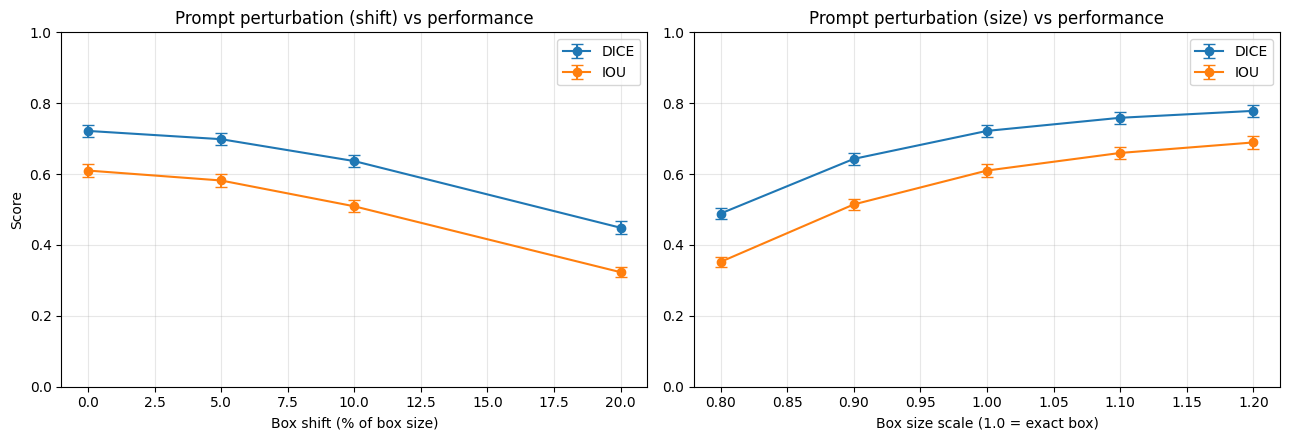

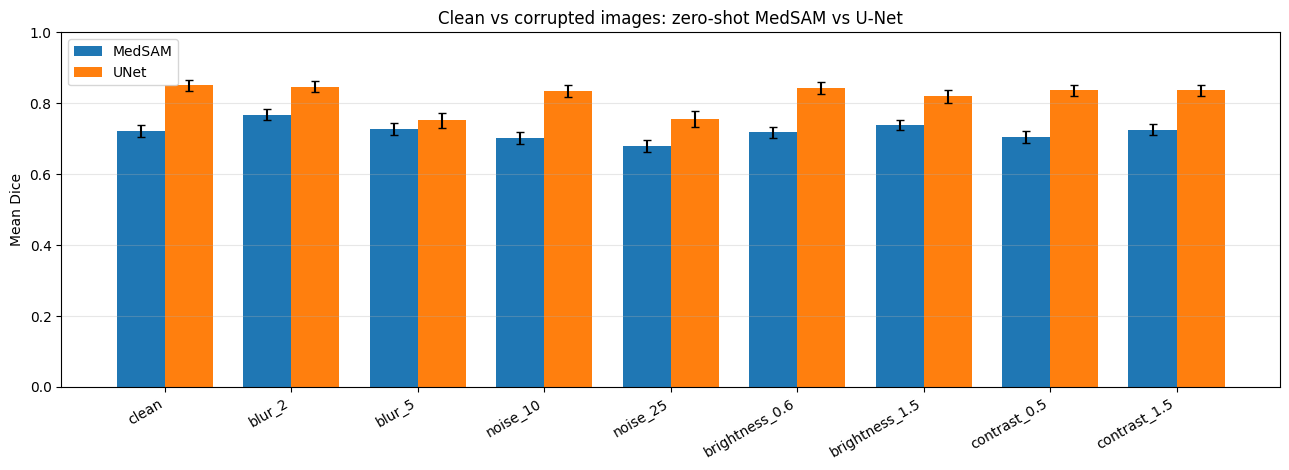

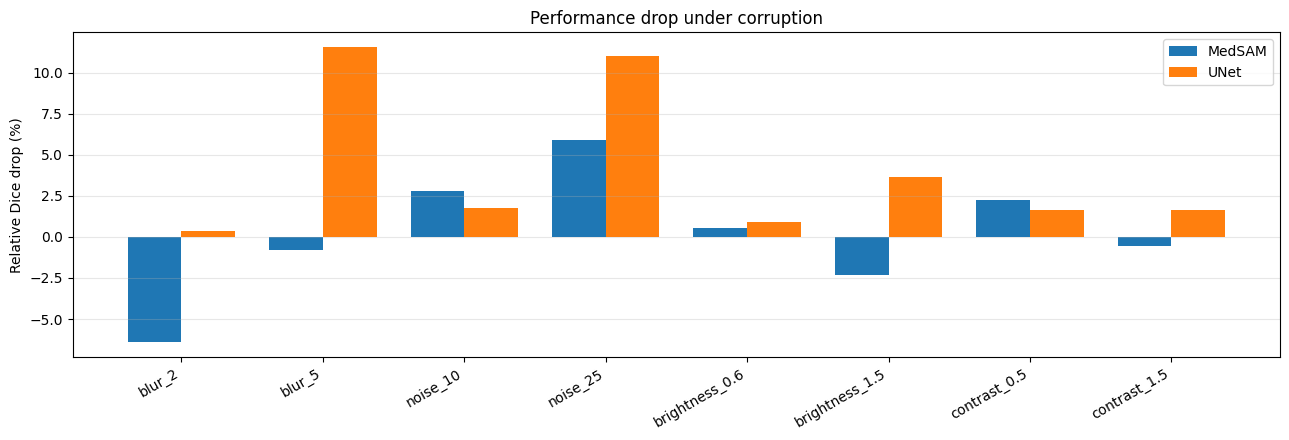

In [15]:
# ---- Figure 1: Prompt perturbation ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
shift_conds, shifts = ["clean", "shift_5", "shift_10", "shift_20"], [0, 5, 10, 20]
for metric in ["dice", "iou"]:
    means = [df[(df.model=="MedSAM")&(df.cond==c)][metric].mean() for c in shift_conds]
    sems  = [df[(df.model=="MedSAM")&(df.cond==c)][metric].sem()  for c in shift_conds]
    ax[0].errorbar(shifts, means, yerr=sems, marker="o", capsize=4, label=metric.upper())
ax[0].set_xlabel("Box shift (% of box size)"); ax[0].set_ylabel("Score")
ax[0].set_title("Prompt perturbation (shift) vs performance"); ax[0].set_ylim(0, 1); ax[0].legend(); ax[0].grid(alpha=.3)

scale_conds = ["scale_0.8", "scale_0.9", "clean", "scale_1.1", "scale_1.2"]
scales = [0.8, 0.9, 1.0, 1.1, 1.2]
for metric in ["dice", "iou"]:
    means = [df[(df.model=="MedSAM")&(df.cond==c)][metric].mean() for c in scale_conds]
    sems  = [df[(df.model=="MedSAM")&(df.cond==c)][metric].sem()  for c in scale_conds]
    ax[1].errorbar(scales, means, yerr=sems, marker="o", capsize=4, label=metric.upper())
ax[1].set_xlabel("Box size scale (1.0 = exact box)"); ax[1].set_title("Prompt perturbation (size) vs performance")
ax[1].set_ylim(0, 1); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("figures/fig1_prompt_robustness.png", dpi=200); plt.show()

# ---- Figure 2: Clean vs corrupted (MedSAM vs UNet) ----
conds = ["clean"] + corr_conds
x = np.arange(len(conds)); w = 0.38
plt.figure(figsize=(13, 4.8))
for k, model in enumerate(["MedSAM", "UNet"]):
    m = [df[(df.model==model)&(df.cond==c)].dice.mean() for c in conds]
    e = [df[(df.model==model)&(df.cond==c)].dice.sem()  for c in conds]
    plt.bar(x + (k - 0.5) * w, m, w, yerr=e, capsize=3, label=model)
plt.xticks(x, conds, rotation=30, ha="right"); plt.ylabel("Mean Dice"); plt.ylim(0, 1)
plt.title("Clean vs corrupted images: zero-shot MedSAM vs U-Net"); plt.legend(); plt.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig("figures/fig2_corruption_comparison.png", dpi=200); plt.show()

# ---- Figure 3: Relative drop (%) ----
plt.figure(figsize=(13, 4.5))
for k, model in enumerate(["MedSAM", "UNet"]):
    t = drop_table(model, corr_conds)
    plt.bar(np.arange(len(corr_conds)) + (k - 0.5) * w, t.rel_drop_pct, w, label=model)
plt.xticks(np.arange(len(corr_conds)), corr_conds, rotation=30, ha="right")
plt.ylabel("Relative Dice drop (%)"); plt.title("Performance drop under corruption"); plt.legend(); plt.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig("figures/fig3_relative_drop.png", dpi=200); plt.show()

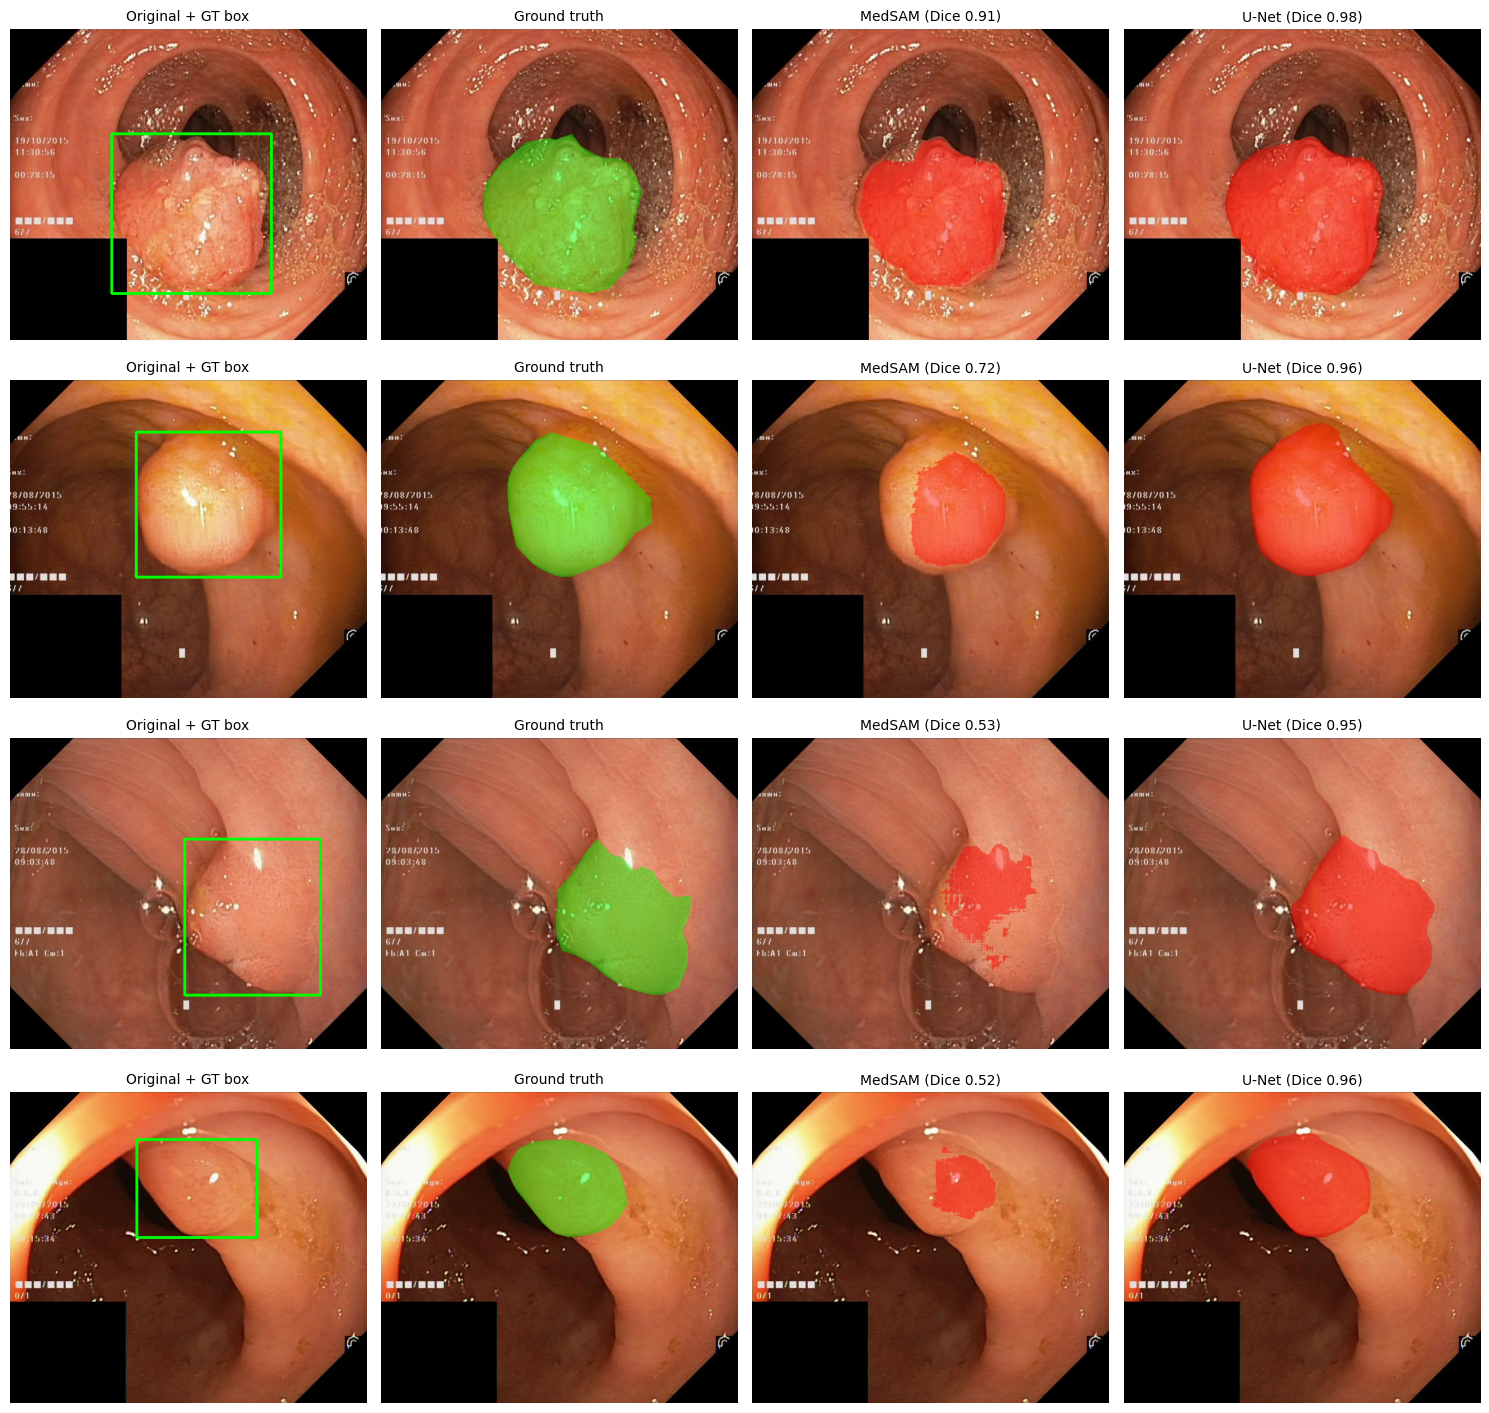

In [16]:
def overlay(img, mask, color=(255, 0, 0), alpha=0.45):
    out = img.copy().astype(np.float32)
    m = mask.astype(bool)
    out[m] = (1 - alpha) * out[m] + alpha * np.array(color, dtype=np.float32)
    return out.astype(np.uint8)

def draw_box(img, box, color=(0, 255, 0)):
    out = img.copy()
    cv2.rectangle(out, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), color, 3)
    return out

sel = random.Random(SEED).sample(range(len(test_names)), 4)
fig, axes = plt.subplots(len(sel), 4, figsize=(15, 3.6 * len(sel)))
for r, idx in enumerate(sel):
    img, gt = load_pair(test_names[idx]); box = mask_to_box(gt)
    pm = medsam_from_image(img, box); pu = unet_predict(img)
    panels = [(draw_box(img, box), "Original + GT box"),
              (overlay(img, gt, (0, 255, 0)), "Ground truth"),
              (overlay(img, pm), f"MedSAM (Dice {dice_iou(pm, gt)[0]:.2f})"),
              (overlay(img, pu), f"U-Net (Dice {dice_iou(pu, gt)[0]:.2f})")]
    for c, (im, t) in enumerate(panels):
        axes[r, c].imshow(im); axes[r, c].set_title(t, fontsize=10); axes[r, c].axis("off")
plt.tight_layout(); plt.savefig("figures/fig4_qualitative.png", dpi=200); plt.show()

Most damaging corruption (MedSAM): noise_25


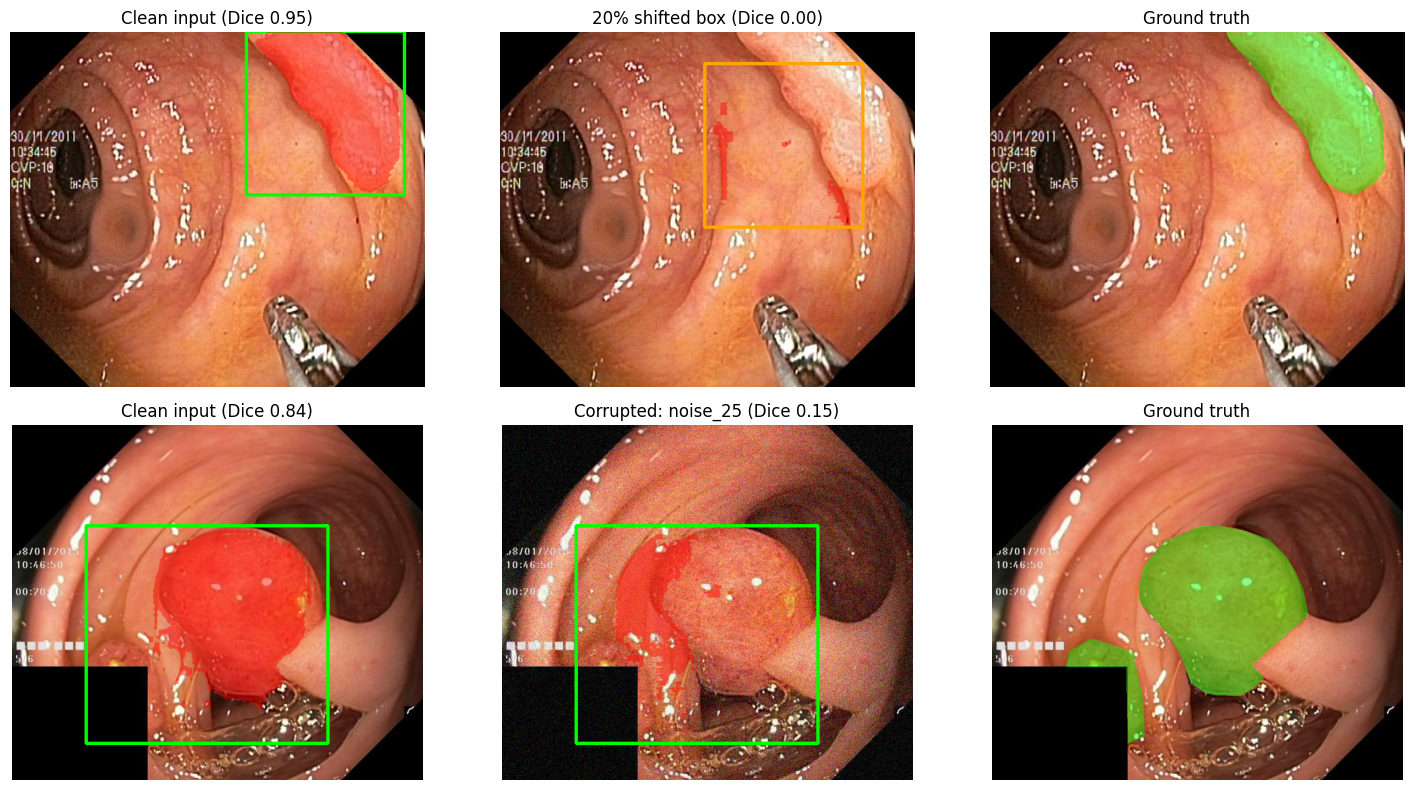

In [17]:
med = df[df.model == "MedSAM"].pivot_table(index="image", columns="cond", values="dice")
worst_c = max(corr_conds, key=lambda c: med["clean"].mean() - med[c].mean())
print("Most damaging corruption (MedSAM):", worst_c)

name_shift = (med["clean"] - med["shift_20"]).idxmax()
name_corr  = (med["clean"] - med[worst_c]).idxmax()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, (name, kind) in enumerate([(name_shift, "shift_20"), (name_corr, worst_c)]):
    idx = test_names.index(name)
    img, gt = load_pair(name); H, W = gt.shape; box = mask_to_box(gt)
    p_clean = medsam_from_image(img, box)
    if kind == "shift_20":
        b2 = shift_box(box, 0.20, get_signs(idx), W, H)
        img2, p_pert = img, medsam_from_image(img, b2)
        left  = draw_box(img, box);  right = draw_box(img2, b2, (255, 165, 0))
        rt = "20% shifted box"
    else:
        img2 = CORRUPTIONS[kind](img, np.random.default_rng(SEED + idx))
        p_pert = medsam_from_image(img2, box)
        left, right = draw_box(img, box), draw_box(img2, box)
        rt = f"Corrupted: {kind}"
    axes[r, 0].imshow(overlay(left, p_clean));  axes[r, 0].set_title(f"Clean input (Dice {dice_iou(p_clean, gt)[0]:.2f})")
    axes[r, 1].imshow(overlay(right, p_pert));  axes[r, 1].set_title(f"{rt} (Dice {dice_iou(p_pert, gt)[0]:.2f})")
    axes[r, 2].imshow(overlay(img, gt, (0, 255, 0))); axes[r, 2].set_title("Ground truth")
    for a in axes[r]: a.axis("off")
plt.tight_layout(); plt.savefig("figures/fig5_difficult_cases.png", dpi=200); plt.show()

In [18]:
!zip -qr medsam_kvasir_results.zip figures results
from google.colab import files
files.download("medsam_kvasir_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>